In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import pickle
import os

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder


from pycaret.classification import *
from pycaret.datasets import get_data


## Data Import and Converting the data as a Pandas Dataframe
* We have 11 Categorical Features and 5 Numerical Features

In [4]:
df = get_data("bank")
data = df[0:33000]
test_data = data[33000:]
data.info()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33000 entries, 0 to 32999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        33000 non-null  int64 
 1   job        33000 non-null  object
 2   marital    33000 non-null  object
 3   education  33000 non-null  object
 4   default    33000 non-null  object
 5   balance    33000 non-null  int64 
 6   housing    33000 non-null  object
 7   loan       33000 non-null  object
 8   contact    33000 non-null  object
 9   day        33000 non-null  int64 
 10  month      33000 non-null  object
 11  duration   33000 non-null  int64 
 12  campaign   33000 non-null  int64 
 13  pdays      33000 non-null  int64 
 14  previous   33000 non-null  int64 
 15  poutcome   33000 non-null  object
 16  deposit    33000 non-null  object
dtypes: int64(7), object(10)
memory usage: 4.3+ MB


# Detailed Column Descriptions
## Bank Client Data:
* age (numeric)
* job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services")
* marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
* education (categorical: "unknown","secondary","primary","tertiary")
* default: has credit in default? (binary: "yes","no")
* balance: average yearly balance, in euros (numeric)
* housing: has housing loan? (binary: "yes","no")
* loan: has personal loan? (binary: "yes","no")
## Related with the last contact of the current campaign:
* contact: contact communication type (categorical: "unknown","telephone","cellular")
* day: last contact day of the month (numeric)
* month: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec")
* duration: last contact duration, in seconds (numeric)
## Other Attributes:
* campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
* pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
* previous: number of contacts performed before this campaign and for this client (numeric)
* poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
## Output Variable (desired target):
* y - has the client subscribed a term deposit? (binary: "yes","no")

In [5]:
# Renaming the columns
data = data.rename(columns={"default": "default_credit",
                            "housing":"housing_loan",
                            "loan":"personal_loan", 
                            "poutcome": "prev_attempt"})
columns = data.columns
test_data = test_data.rename(columns={"default": "default_credit",
                            "housing":"housing_loan",
                            "loan":"personal_loan", 
                            "poutcome": "prev_attempt"})
# Adding the missing columns in the test dataset
# test_data['pdays']=0
# test_data['previous'] = 0
# test_data['y']=0
# test_data = test_data[columns]
# test_data = test_data.drop(['y'], axis=1)

# Splitting the dataset as per the categorical and numerical features For EDA
cat_data = data.select_dtypes(include=['object'])
num_data = data.select_dtypes(include=['int64'])
num_data["pdays"].replace({999: 0}, inplace=True)
print(columns)

Index(['age', 'job', 'marital', 'education', 'default_credit', 'balance',
       'housing_loan', 'personal_loan', 'contact', 'day', 'month', 'duration',
       'campaign', 'pdays', 'previous', 'prev_attempt', 'deposit'],
      dtype='object')


## Defining the functions to plot the categorical and numerical features independently

In [6]:
def univariate_cat_plots(df):
    for feature in df.columns:
        plt.figure(figsize=(12,6))
        sns.set_theme(context='notebook',style='darkgrid',palette='deep',color_codes=True)
        sns.countplot(x=feature,data=df,palette="dark",orient='v')
        plt.xlabel(feature)
        plt.title("Univariate analysis of categorical feature")
        plt.show()

def multivariate_cat_plots(df):
    for feature in df.columns:
        plt.figure(figsize=(12,6))
        sns.set_theme(context='notebook',style='whitegrid',palette='deep',color_codes=True)
        sns.countplot(x=feature,data=df,palette="dark",hue = 'deposit',orient='v')
        plt.xlabel(feature)
        plt.title("Biivariate analysis of categorical feature")
        plt.show()

def num_plots(df):
    for feature in df.columns:
        plt.figure(figsize=(12,6))
        sns.kdeplot(data=df, x =feature)
        plt.xlabel(feature)
        plt.title("Univariate Analysis of Numerical Features")
        plt.show()

        

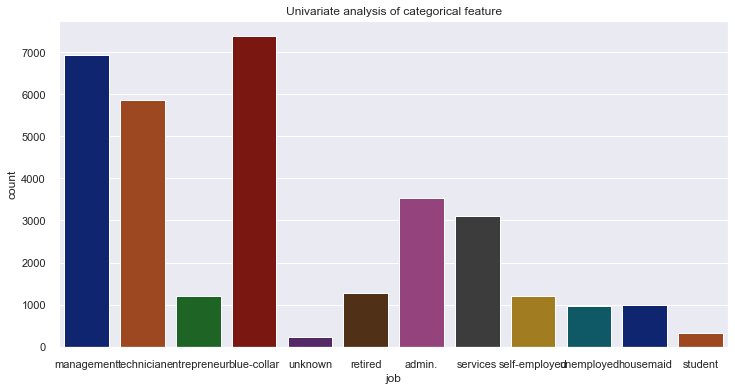

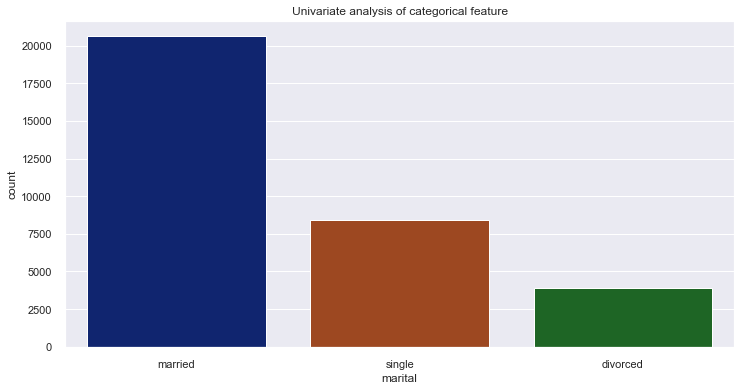

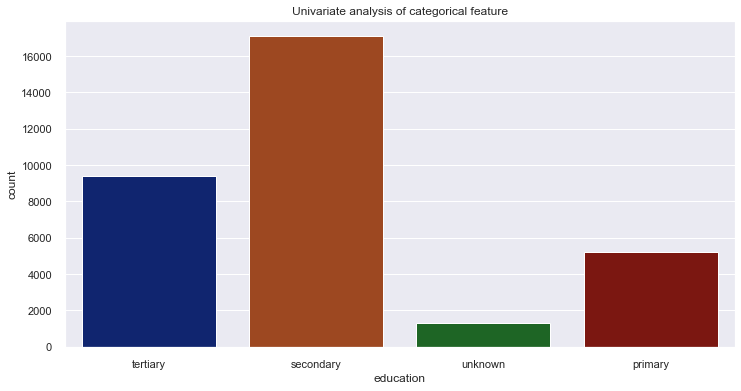

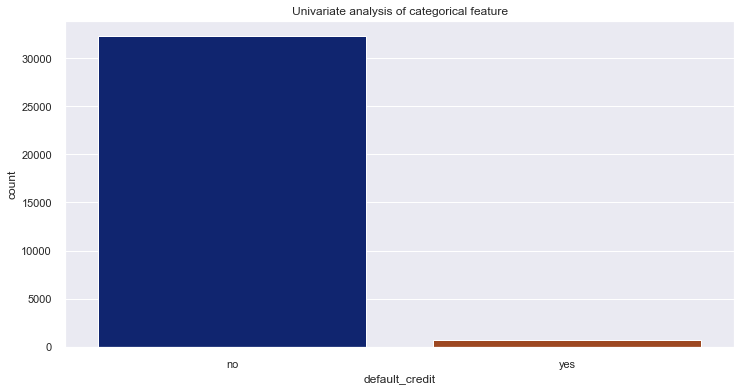

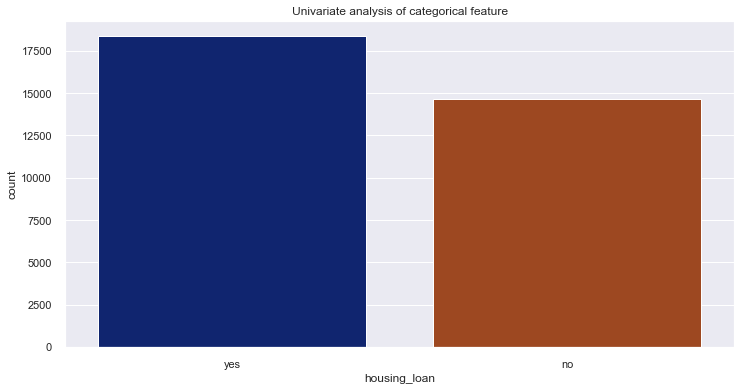

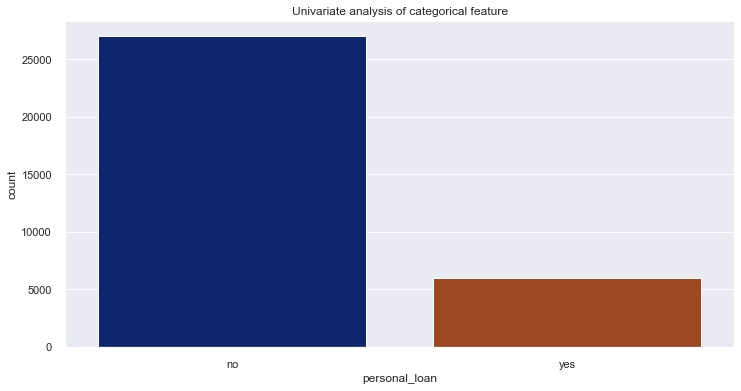

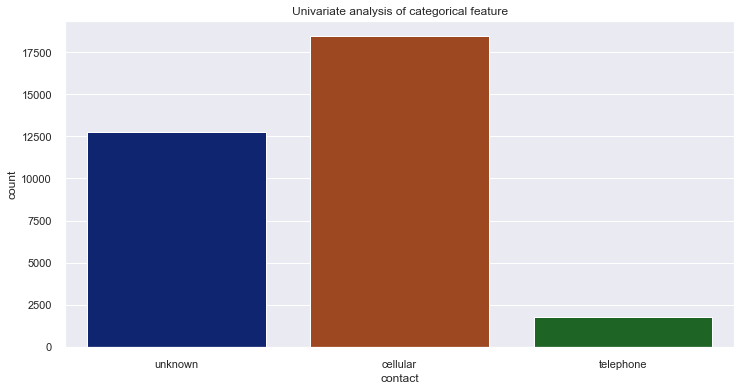

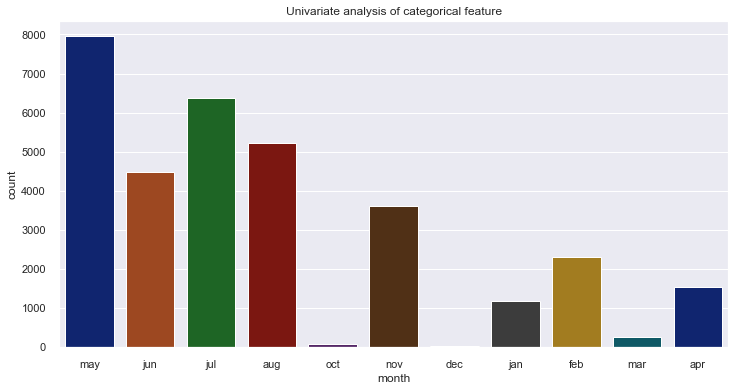

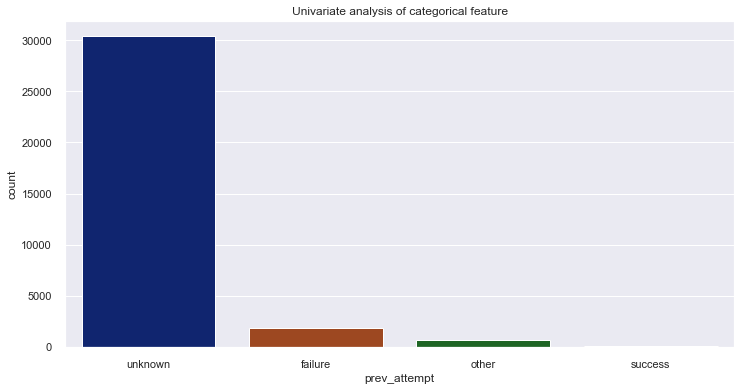

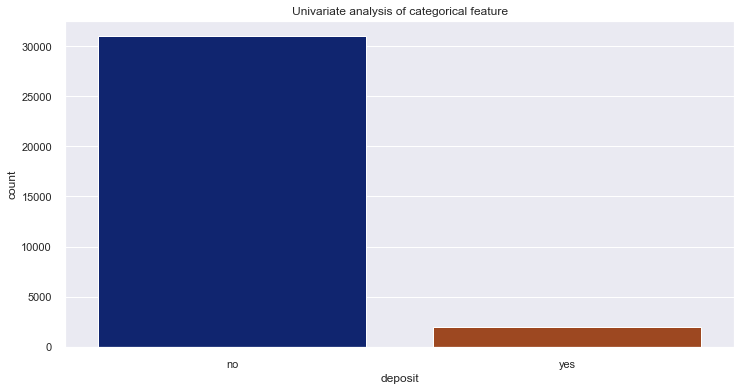

In [7]:
univariate_cat_plots(cat_data)        

## Univariate Analyis of Categorical Features
* Job -Job has 12 unique values. Most of the clients in the bank takes up Blue collar, admin or technical jobs.
* Marital - This column has 4 unique values where most of the clients are 'married'. There are no 'unknown' value which represents every client is either married, divorced or single
* Education - Almost 100% of the clients in the dataset are literates. More than 30% of the clients have a university degree and the rest has atleast basic 4 years of education 
* Default Credit - This column has 3 unique values. Most of the clients does not have any previous credit
* Housing_loan - Almost 50% of the clients have housing loan and the clients who does not have housing loan are about the same ratio.
* Personal Loan - Almost 80% of the clients does not have any previous personal loans.
* These above three features (Default Credit, Housing Loan, Personal Loan) looks very important and could be more dependent on the 'y' feature i.e client will invest or not
* Month - We have high values for the (nov, jul, may, jun, aug) months. Which represents the clients have been contacted in the later half of the year. 
* Prev_attempt - This feature represents whether the client was contacted before regarding the investment. It is very evident that most of the clients are not even contacted as the plot shows high values of 'nonexistent'

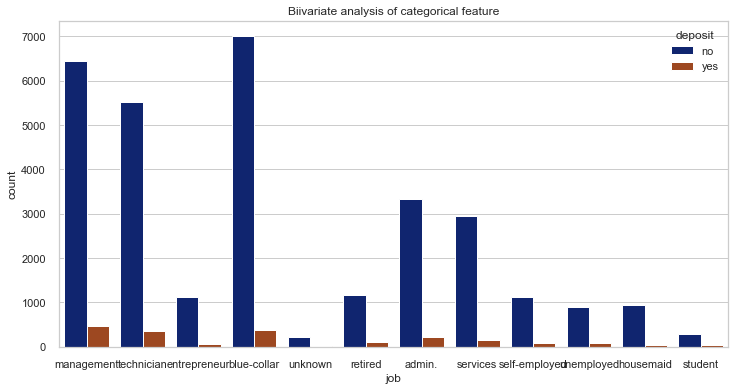

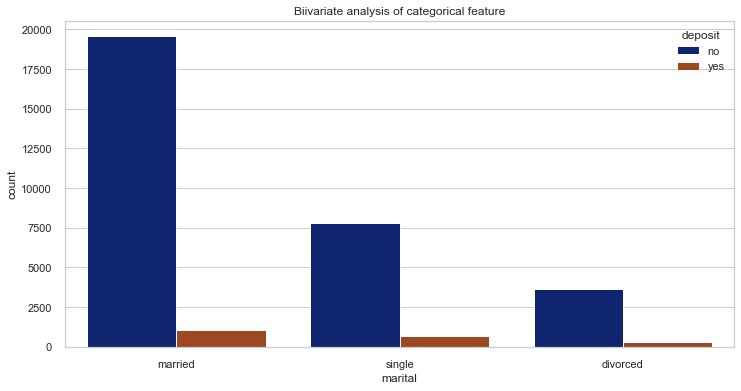

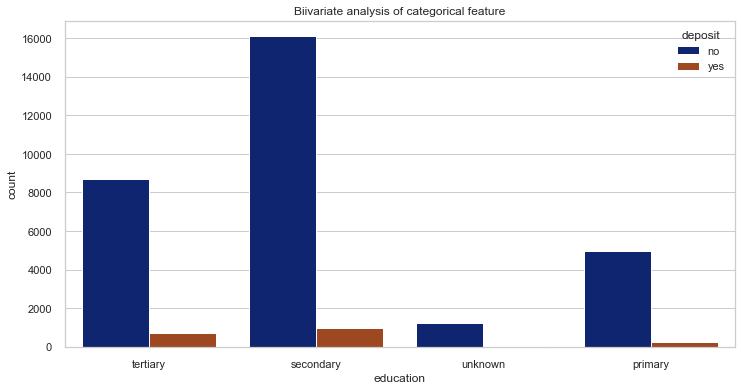

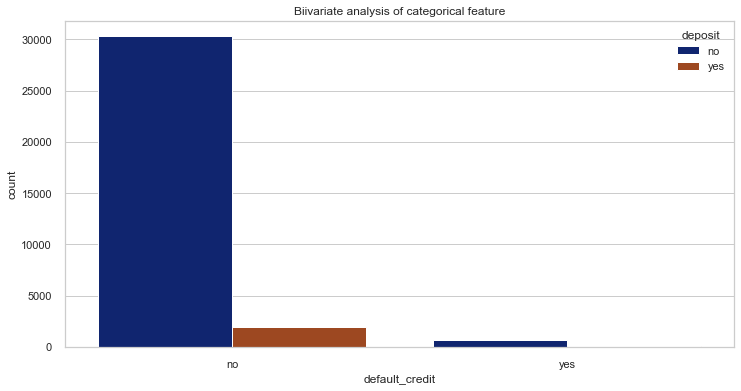

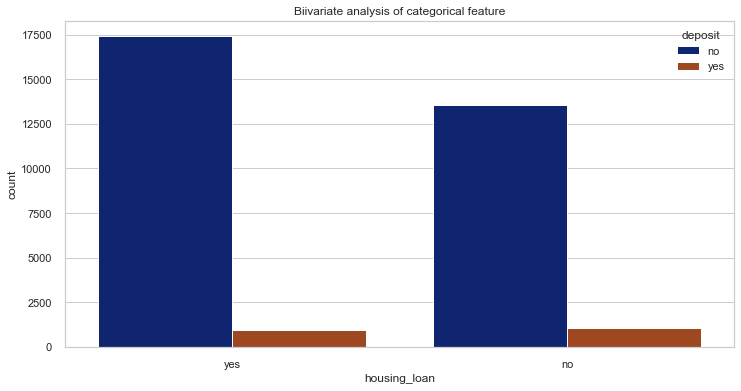

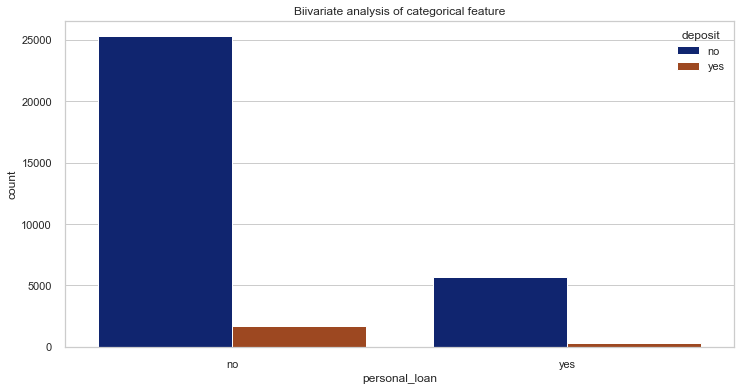

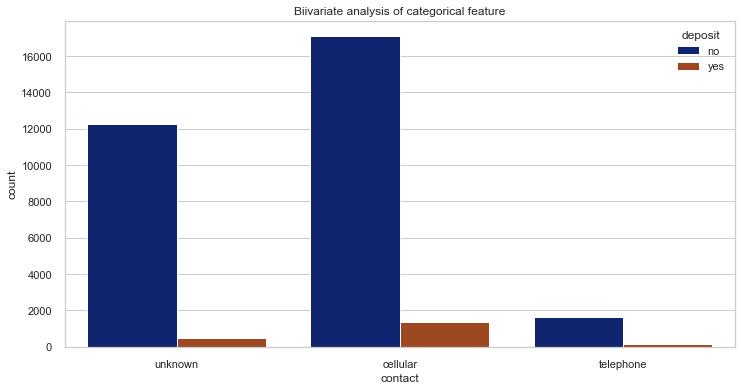

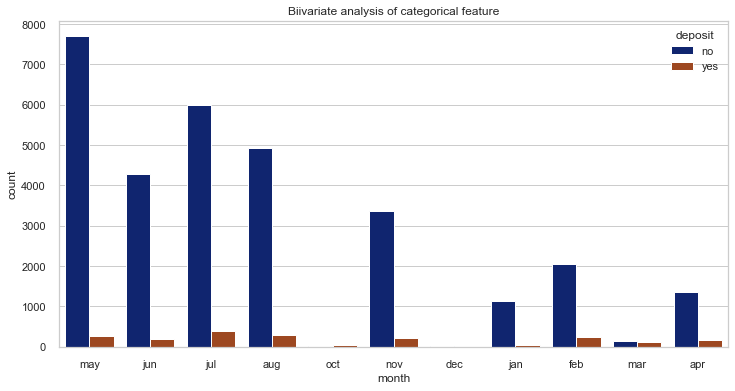

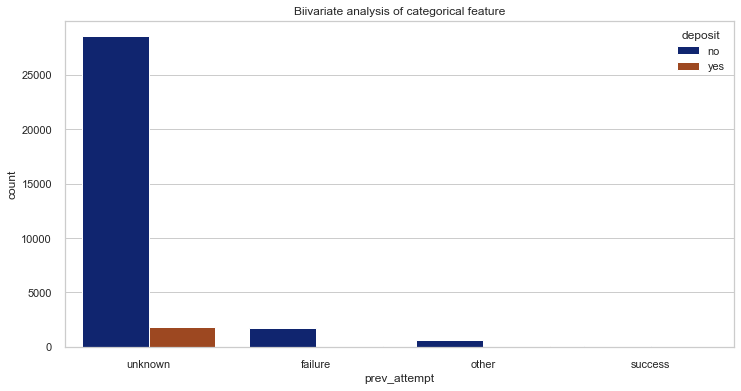

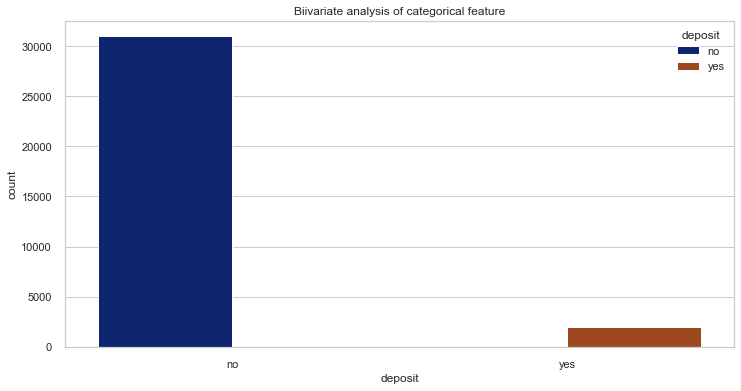

In [8]:
multivariate_cat_plots(cat_data)

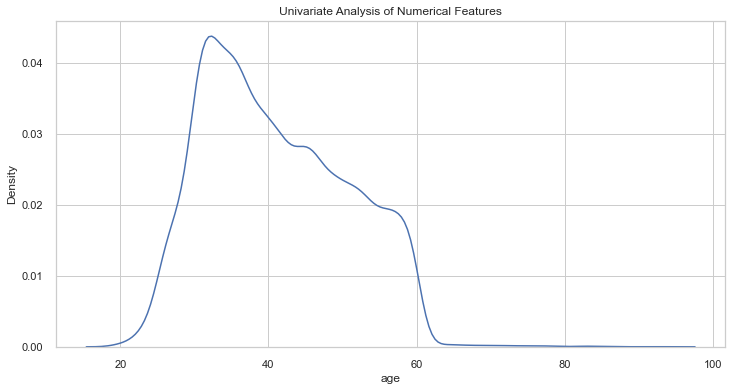

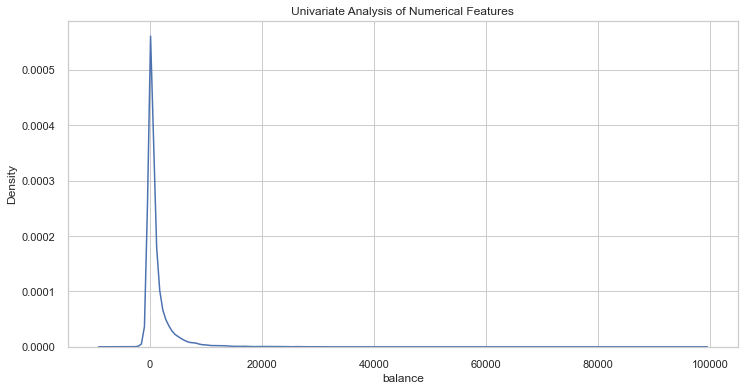

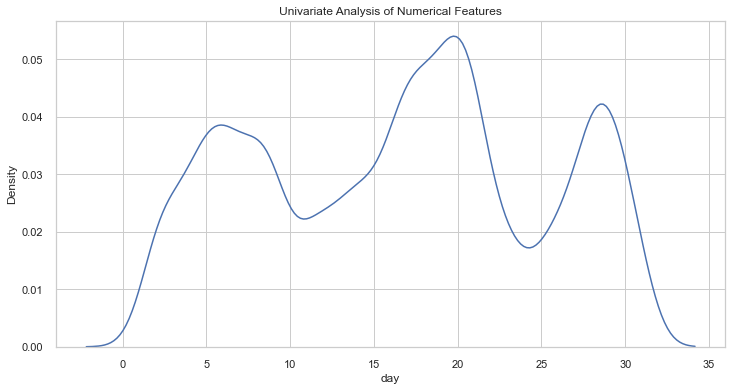

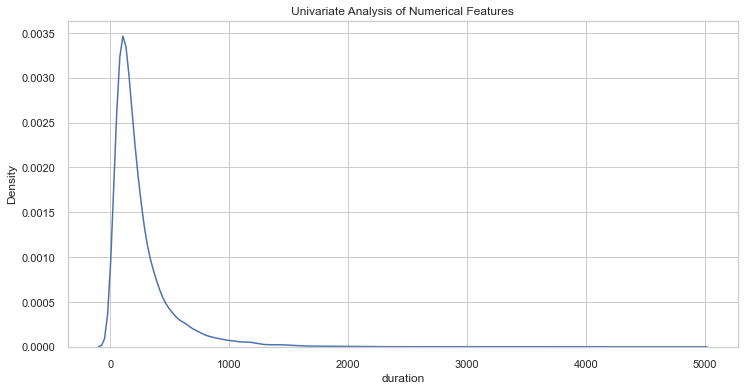

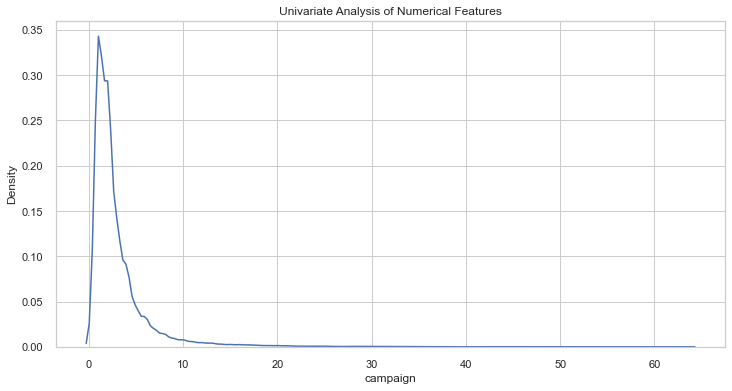

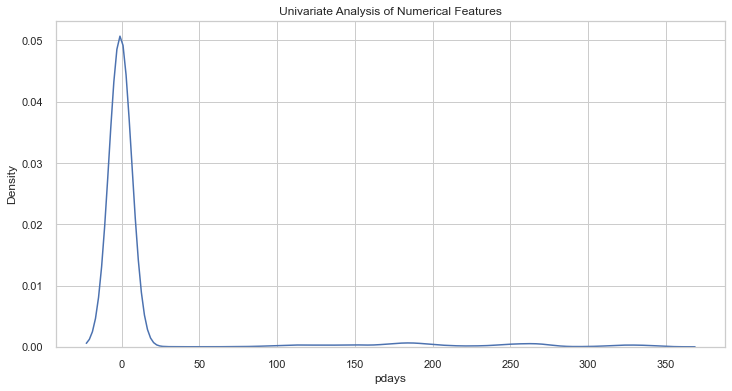

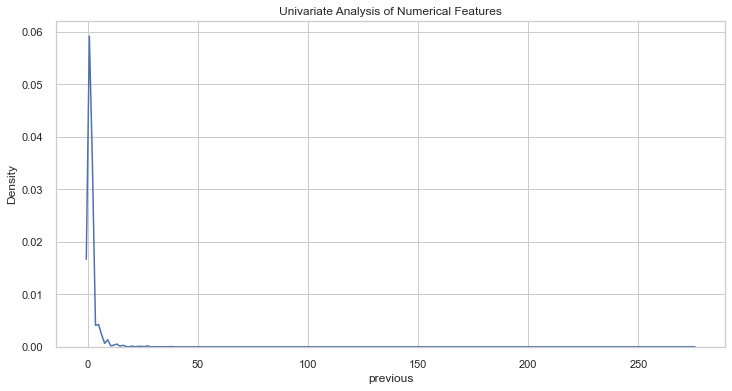

In [9]:
num_plots(num_data)

## Analysis of the Numerical Features
* Age
* Duration
* Campaign
* pdays
* Previous

* All the above features have the normal distribution as we can see from the plots above. 

In [10]:
le = LabelEncoder()
cat_data= cat_data[cat_data.columns].apply(lambda col: le.fit_transform(col))

# Merging both dataframes
bank_data = pd.concat([cat_data,num_data],axis =1)
bank_data = bank_data[columns]
bank_data.head()


,age,job,marital,education,default_credit,balance,housing_loan,personal_loan,contact,day,month,duration,campaign,pdays,previous,prev_attempt,deposit
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


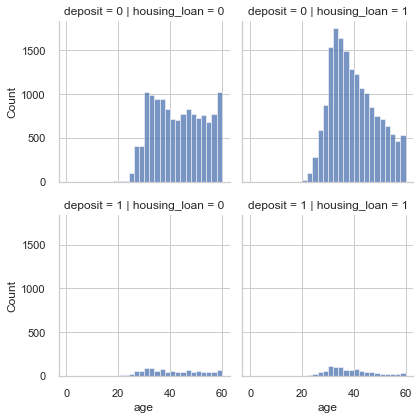

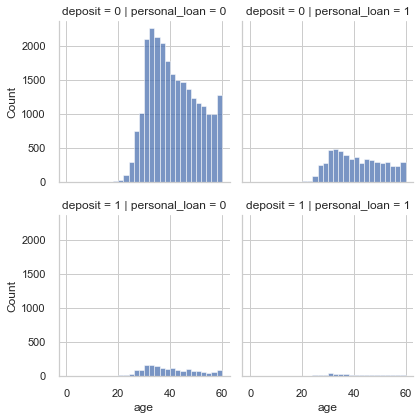

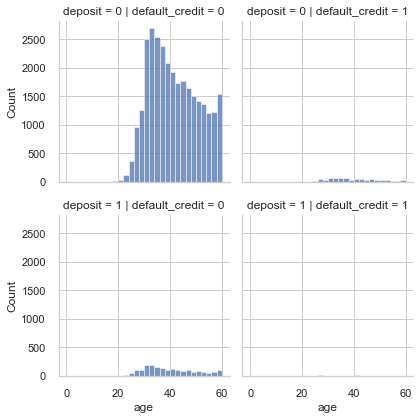

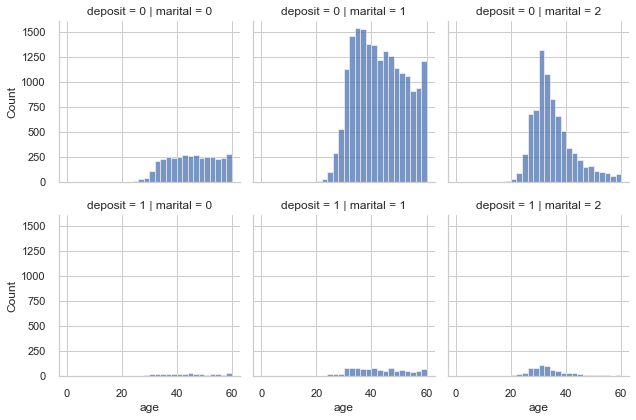

In [11]:
def grid_plots(bank_data):    
    for feature in ['housing_loan','personal_loan','default_credit','marital']:
        sns.color_palette('tab10')
        grid = sns.FacetGrid(bank_data, col=feature, row='deposit')
        grid.map_dataframe(sns.histplot,x='age',binwidth=2, binrange=(0, 60))
        plt.show()
grid_plots(bank_data)

As we can see from the above box plots we definitely identify the data present outside the box plots.
* We now try to remove the outliers and find out how the model performs. 



# Creating the Model and training the Model - PyCaret

In [13]:
bank_data.shape

(33000, 17)

In [11]:
env = setup(data= bank_data, target='deposit')

,Description,Value
0,Session id,2021
1,Target,deposit
2,Target type,Binary
3,Original data shape,"(33000, 17)"
4,Transformed data shape,"(33000, 17)"
5,Transformed train set shape,"(23100, 17)"
6,Transformed test set shape,"(9900, 17)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,simple


In [12]:
model = compare_models(fold =10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9474,0.9542,0.3838,0.6060,0.4687,0.4426,0.4560,0.6660
gbc,Gradient Boosting Classifier,0.9459,0.9476,0.3381,0.5958,0.4310,0.4049,0.4231,1.3490
rf,Random Forest Classifier,0.9453,0.9458,0.3088,0.5935,0.4054,0.3797,0.4025,1.3350
lr,Logistic Regression,0.9440,0.8914,0.2266,0.6043,0.3285,0.3056,0.3466,1.5510
et,Extra Trees Classifier,0.9436,0.9393,0.2209,0.5982,0.3215,0.2985,0.3400,1.0370
xgboost,Extreme Gradient Boosting,0.9430,0.9492,0.3752,0.5448,0.4435,0.4146,0.4231,1.0040
lda,Linear Discriminant Analysis,0.9424,0.8950,0.4246,0.5322,0.4718,0.4418,0.4452,0.4030
ridge,Ridge Classifier,0.9421,0.0000,0.1101,0.6274,0.1867,0.1717,0.2455,0.3230
ada,Ada Boost Classifier,0.9413,0.9308,0.3160,0.5277,0.3949,0.3661,0.3796,0.6600
dummy,Dummy Classifier,0.9394,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3590


In [13]:
best_model = create_model(model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9489,0.9523,0.3813,0.6235,0.4732,0.4480,0.4630
1,0.9519,0.9578,0.4500,0.6495,0.5316,0.5072,0.5167
2,0.9446,0.9514,0.3714,0.5652,0.4483,0.4204,0.4307
3,0.9519,0.9646,0.4214,0.6629,0.5153,0.4913,0.5053
4,0.9424,0.9500,0.4214,0.5315,0.4701,0.4401,0.4434
5,0.9433,0.9499,0.3571,0.5495,0.4329,0.4045,0.4149
6,0.9515,0.9619,0.4071,0.6628,0.5044,0.4805,0.4963
7,0.9446,0.9498,0.3357,0.5732,0.4234,0.3964,0.4121
8,0.9489,0.9537,0.3857,0.6279,0.4779,0.4526,0.4675


In [14]:
tuned_model = tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9502,0.9512,0.4101,0.6333,0.4978,0.4729,0.4853
1,0.9481,0.9488,0.4286,0.6000,0.5000,0.4734,0.4809
2,0.9472,0.9534,0.3857,0.6000,0.4696,0.4432,0.4552
3,0.9537,0.9630,0.4214,0.6941,0.5244,0.5016,0.5189
4,0.9398,0.9466,0.3929,0.5046,0.4418,0.4105,0.4141
5,0.9468,0.9418,0.3714,0.5977,0.4581,0.4318,0.4453
6,0.9485,0.9489,0.3500,0.6364,0.4516,0.4270,0.4481
7,0.9424,0.9419,0.2714,0.5507,0.3636,0.3371,0.3604
8,0.9446,0.9487,0.3357,0.5732,0.4234,0.3964,0.4121


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


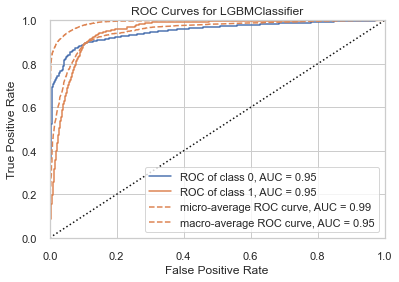

In [15]:
plot_model(tuned_model)

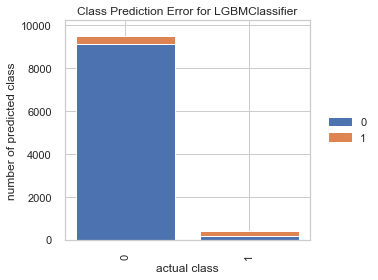

In [16]:
plot_model(tuned_model,plot='error')

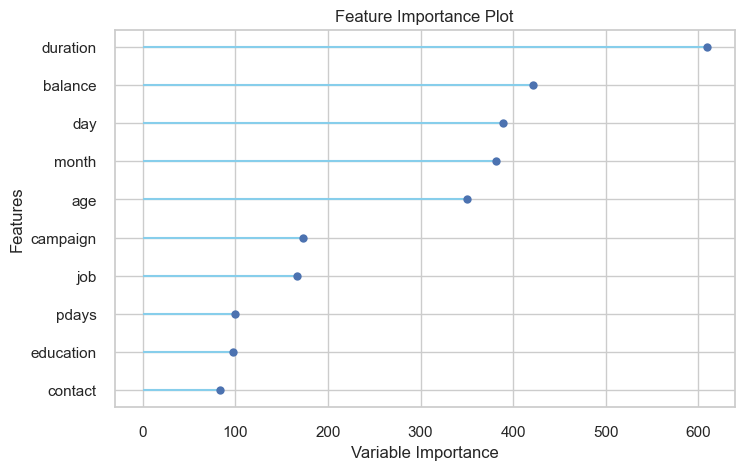

In [17]:
plot_model(tuned_model,plot='feature')

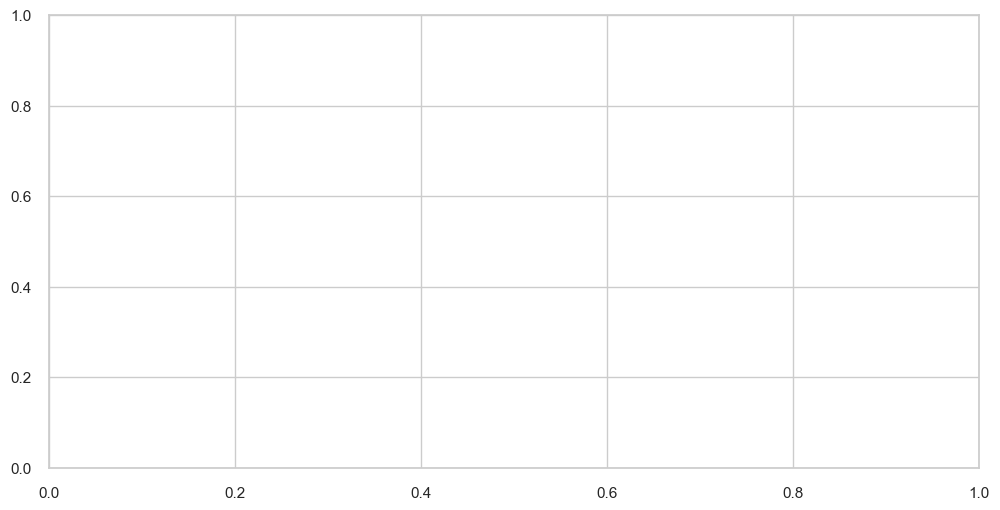

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [18]:
evaluate_model(tuned_model)

In [19]:
pickle.dump(model, open('model.pkl', 'wb'))